### **Librerías**

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

### **Parámetros**

In [2]:
os.chdir("/Users/juanchacon/Library/Mobile Documents/com~apple~CloudDocs/GitHub/bot_futuros")

SILVER_DATA_PATH = os.getcwd() + "/data/silver"
RESULTS_PATH = os.getcwd() + "/notebooks/EDA/results_preds"
FILE_PATH = f"{SILVER_DATA_PATH}/datos_DEMANDA_COMPRADOR.csv"
SIMULATIONS = 1000       
DAYS_TO_FORECAST = 365   
ALIGNMENT_LAG = 364      # 52 semanas exactas para alinear días de la semana (Lunes con Lunes)
TREND_WINDOW_DAYS = 120

### **Funciones**

In [3]:
# ==========================================
# 1. FUNCIÓN DE CARGA DE DATOS
# ==========================================


def load_data(filepath):
    print(f"Cargando datos desde: {filepath}...")
    df = pd.read_csv(filepath)
    df['Fecha'] = pd.to_datetime(df['Fecha'])
    df = df.set_index('Fecha')
    df = df.sort_index()
    return df

def get_trend_slope(series, days):
    """
    Calcula la pendiente de crecimiento diario (kWh/día) 
    basado en los últimos 'days' días usando regresión lineal.
    """
    y = series.iloc[-days:].values
    X = np.arange(len(y)).reshape(-1, 1)
    
    model = LinearRegression()
    model.fit(X, y)
    
    # La pendiente (coef_) nos dice cuánto crece la demanda por día en promedio
    return model.coef_[0]

def run_simulation():
    df = load_data(FILE_PATH)
    target_cols = df.columns
    dict_results = {}
    
    for col in target_cols:
        print(f"\n{'='*60}")
        print(f" PROCESANDO: {col}")
        print(f"{'='*60}")
        
        series = df[col]
        
        # 1. ANÁLISIS DE TENDENCIAS
        # -------------------------
        # A. Tendencia Reciente (Target): ¿Qué tan rápido estamos creciendo HOY?
        # Usamos 120 días para capturar la tendencia positiva sólida reciente
        target_slope = get_trend_slope(series, days=TREND_WINDOW_DAYS)
        
        # B. Tendencia Histórica (Base): ¿Qué tan rápido crecía el AÑO PASADO?
        # Calculamos la pendiente del mismo periodo pero hace un año
        hist_slope = get_trend_slope(series.iloc[:-DAYS_TO_FORECAST], days=ALIGNMENT_LAG)
        
        # C. Ajuste (Drift): La diferencia.
        # Si hoy crecemos a 500 kWh/día y el año pasado a 100, 
        # debemos sumar 400 kWh extra cada día a la forma del año pasado.
        drift_adjustment = target_slope - hist_slope
        
        # REGLA DE SEGURIDAD PARA 7-17 Y OTRAS:
        # Si el usuario confirma que la tendencia es positiva, forzamos que el ajuste no sea negativo
        # (evita que un año pasado "malo" nos tumbe el pronóstico)
        if drift_adjustment < 0 and target_slope > 0:
             print(" [Aviso] Ajuste negativo detectado pero tendencia reciente positiva.")
             print(" -> Se usará la tendencia reciente completa para garantizar crecimiento.")
             drift_adjustment = target_slope # Ignoramos la historia negativa, imponemos el crecimiento actual
        
        print(f" -> Crecimiento Diario Reciente: {target_slope:.2f} kWh/día")
        print(f" -> Crecimiento Diario Año Pasado: {hist_slope:.2f} kWh/día")
        print(f" -> Ajuste aplicado al modelo: {drift_adjustment:.2f} kWh/día extra")

        # 2. CONSTRUCCIÓN DE LA SIMULACIÓN
        # --------------------------------
        # Método: "Step-Forward" (Paso adelante)
        # Pronóstico[t] = Pronóstico[t-1] + (Cambio_Hace_Un_Año) + (Ajuste_Tendencia)
        
        # Extraemos los cambios diarios del año pasado (Deltas)
        # Esto captura la estacionalidad (Lunes sube, Domingo baja, Enero sube, etc.)
        last_year_data = series.iloc[-ALIGNMENT_LAG-1:].values
        
        # Calculamos día a día cuánto cambió la demanda hace 364 días
        historical_deltas = []
        for i in range(DAYS_TO_FORECAST):
            # Índice correspondiente al día simétrico del año pasado
            # +1 porque diff necesita el previo
            idx = i + 1 
            # Protección por si el forecast es más largo que la historia (loop)
            if idx >= len(last_year_data):
                idx = idx % ALIGNMENT_LAG + 1
            
            # Delta = Valor[i] - Valor[i-1]
            delta = last_year_data[idx] - last_year_data[idx-1]
            historical_deltas.append(delta)
            
        historical_deltas = np.array(historical_deltas)
        
        # 3. MONTE CARLO
        # --------------
        simulated_paths = np.zeros((DAYS_TO_FORECAST, SIMULATIONS))
        
        # Volatilidad para el ruido aleatorio
        daily_vol = series.pct_change().dropna().std()
        current_val = series.iloc[-1]
        
        np.random.seed(42)
        
        # Matriz de Ruido: (Días x Simulaciones)
        # El ruido es proporcional al valor actual (aprox)
        noise_matrix = np.random.normal(loc=0, scale=daily_vol * current_val, size=(DAYS_TO_FORECAST, SIMULATIONS))
        
        # Matriz de Tendencia: 
        # Agregamos un poco de incertidumbre a la pendiente también (+/- 10%)
        slope_uncertainty = np.random.normal(loc=0, scale=abs(drift_adjustment)*0.1, size=(1, SIMULATIONS))
        total_drift_matrix = drift_adjustment + slope_uncertainty
        
        # Matriz Base (Deltas históricos repetidos)
        base_deltas_matrix = np.tile(historical_deltas.reshape(-1, 1), (1, SIMULATIONS))
        
        # CAMBIO TOTAL DIARIO = (Patrón Año Pasado) + (Tendencia Extra) + (Ruido)
        all_daily_changes = base_deltas_matrix + total_drift_matrix + noise_matrix
        
        # ACUMULAR CAMBIOS DESDE EL ÚLTIMO VALOR REAL (ENLACE PERFECTO)
        # Empezamos con el último valor real y vamos sumando los cambios acumulados
        cumulative_changes = np.cumsum(all_daily_changes, axis=0)
        simulated_paths = current_val + cumulative_changes
        
        # 4. RESULTADOS Y GRÁFICOS
        # ------------------------
        future_dates = pd.date_range(start=series.index[-1] + pd.Timedelta(days=1), periods=DAYS_TO_FORECAST)
        
        p10 = np.percentile(simulated_paths, 10, axis=1)
        p50 = np.percentile(simulated_paths, 50, axis=1)
        p90 = np.percentile(simulated_paths, 90, axis=1)
        
        results_df = pd.DataFrame({
            'Fecha': future_dates,
            'Escenario_Bajo_P10': p10,
            'Escenario_Medio_P50': p50,
            'Escenario_Alto_P90': p90
        })
        
        dict_results[col] = results_df
        #csv_name = f'pronostico_tendencia_{col}.csv'
        #results_df.to_csv(csv_name, index=False)
        #print(f" -> Datos guardados: {csv_name}")
        
        # Graficar
        plt.figure(figsize=(12, 6))
        
        # Mostrar historia reciente para verificar el enlace
        plt.plot(series.index[-700:], series.iloc[-700:], label='Historia', color='black', linewidth=2)
        
        # Mostrar Pronóstico
        plt.plot(results_df['Fecha'], results_df['Escenario_Medio_P50'], color='green', linewidth=2, label='Pronóstico (Tendencia Ajustada)')
        #plt.fill_between(results_df['Fecha'], results_df['Escenario_Bajo_P10'], results_df['Escenario_Alto_P90'], 
        #                 color='green', alpha=0.15, label='Rango Probable')
        
        plt.title(f'Simulación  - {col}', fontsize=12)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        #plt.savefig(f'grafico_final_{col}.png')
        plt.show()
    
    return dict_results

Cargando datos desde: /Users/juanchacon/Library/Mobile Documents/com~apple~CloudDocs/GitHub/bot_futuros/data/silver/datos_DEMANDA_COMPRADOR.csv...

 PROCESANDO: Demanda_kWh_0-7
 -> Crecimiento Diario Reciente: 4459.22 kWh/día
 -> Crecimiento Diario Año Pasado: 1061.97 kWh/día
 -> Ajuste aplicado al modelo: 3397.25 kWh/día extra


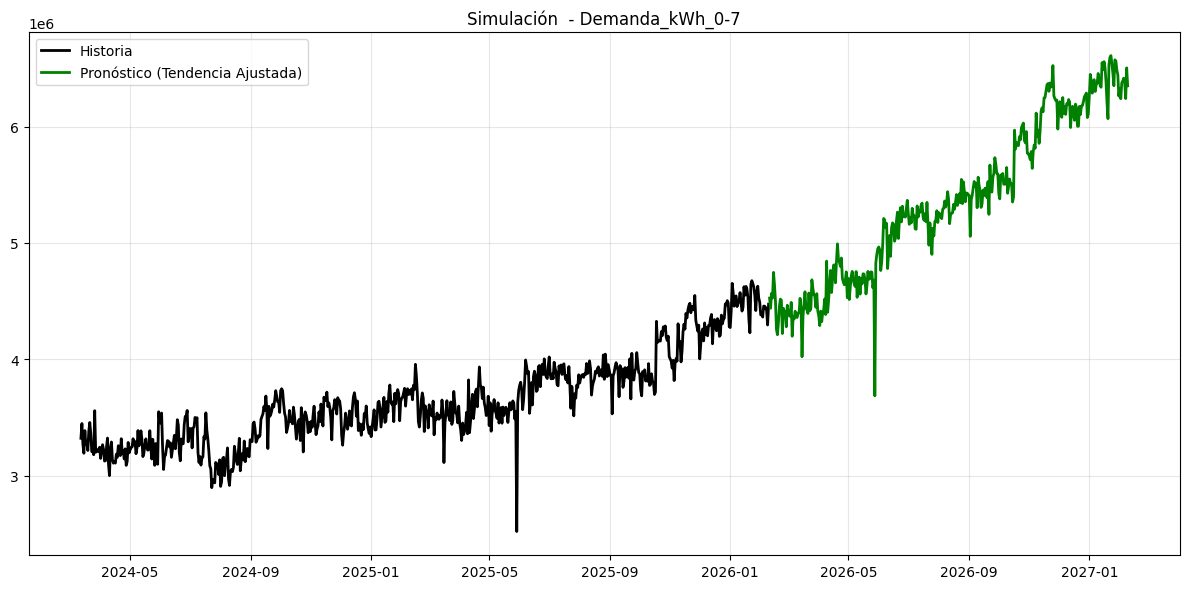


 PROCESANDO: Demanda_kWh_7-17
 -> Crecimiento Diario Reciente: 3921.29 kWh/día
 -> Crecimiento Diario Año Pasado: 906.86 kWh/día
 -> Ajuste aplicado al modelo: 3014.43 kWh/día extra


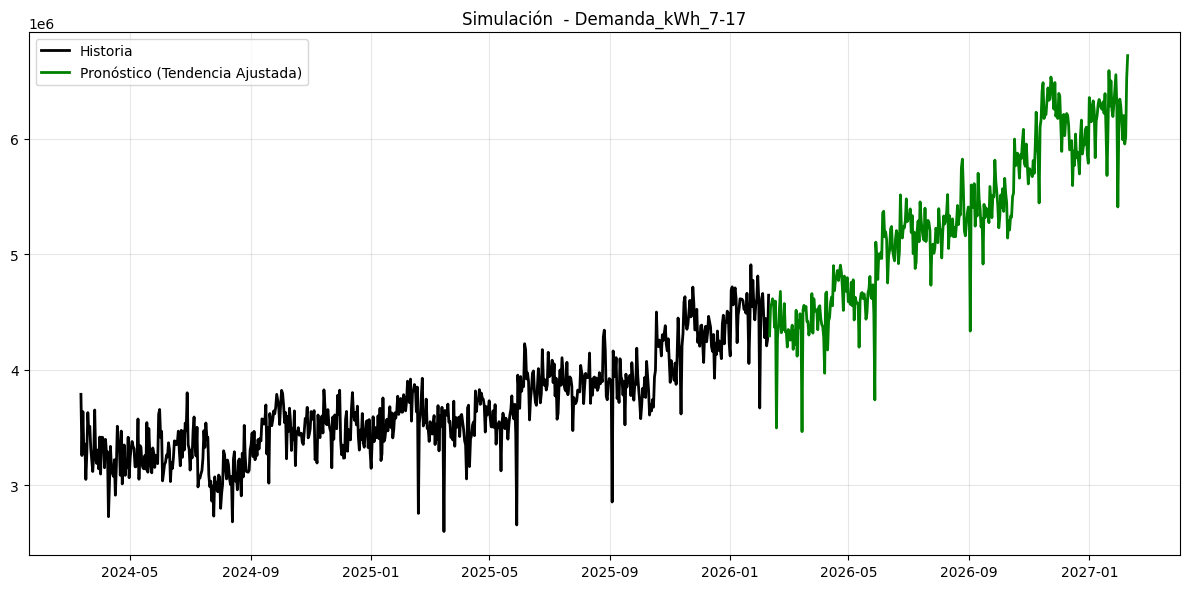


 PROCESANDO: Demanda_kWh_17-23
 -> Crecimiento Diario Reciente: 3708.58 kWh/día
 -> Crecimiento Diario Año Pasado: 996.53 kWh/día
 -> Ajuste aplicado al modelo: 2712.06 kWh/día extra


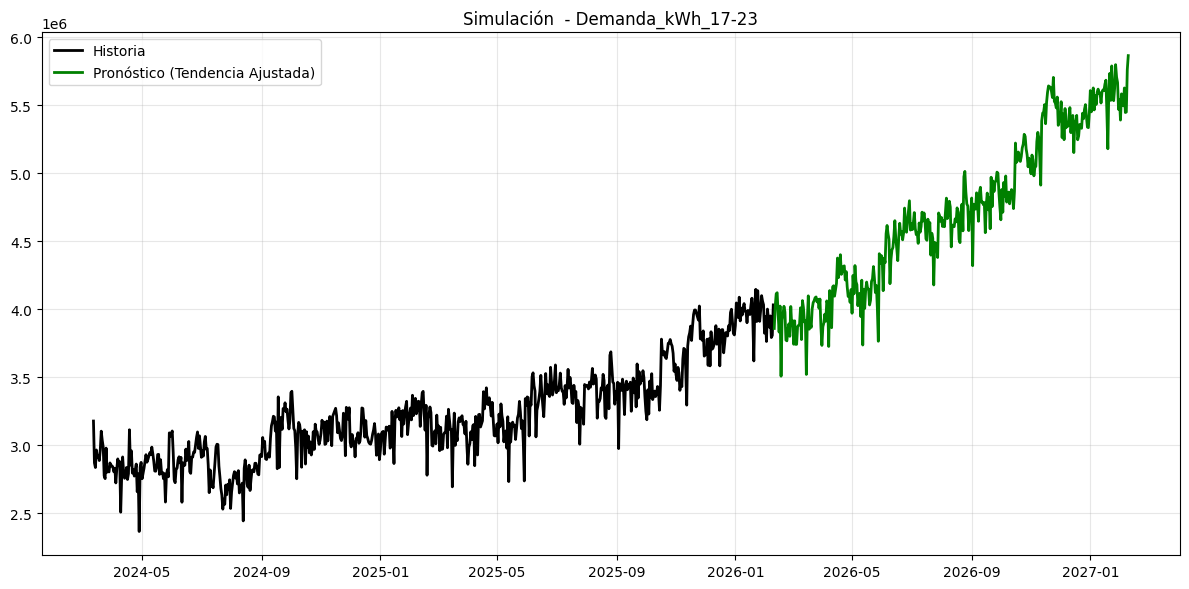


 PROCESANDO: Demanda_kWh_Dia
 -> Crecimiento Diario Reciente: 12089.09 kWh/día
 -> Crecimiento Diario Año Pasado: 2965.35 kWh/día
 -> Ajuste aplicado al modelo: 9123.74 kWh/día extra


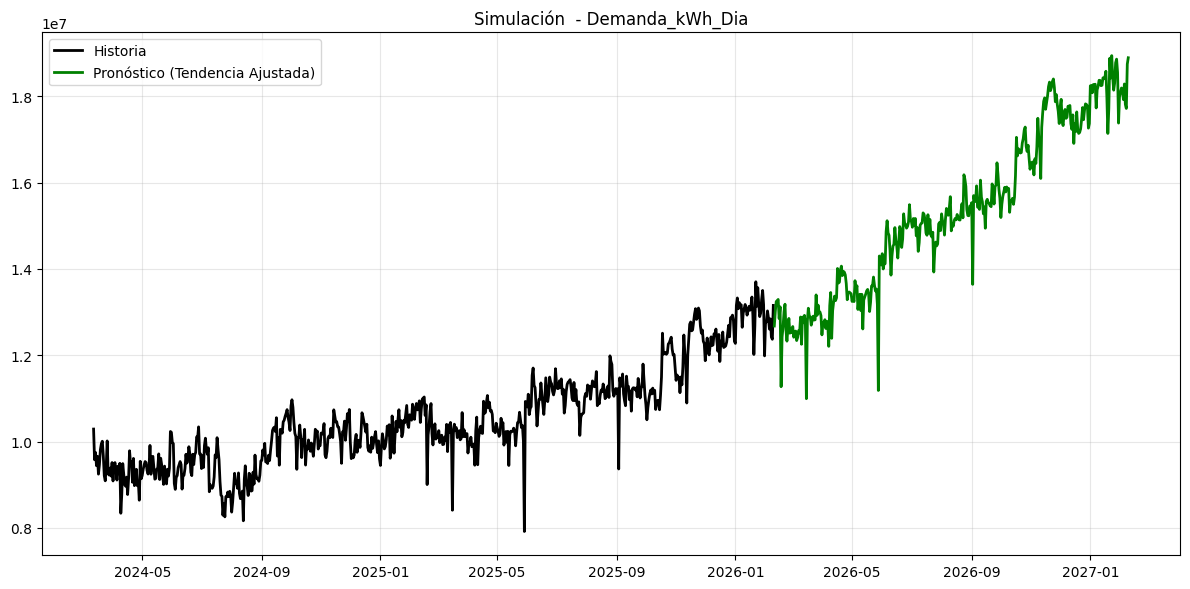

In [4]:
results_df = run_simulation()